In [25]:
import numpy as np
import pandas as pd

In [26]:
# Load the datasets
customers = pd.read_csv("customers_dataset.csv")
orders = pd.read_csv("orders_dataset.csv")
order_items = pd.read_csv("order_items_dataset.csv")
payments = pd.read_csv("order_payments_dataset.csv")
reviews = pd.read_csv("order_reviews_dataset.csv")
products = pd.read_csv("products_dataset.csv")
sellers = pd.read_csv("sellers_dataset.csv")
geo = pd.read_csv("geolocation_dataset.csv")
category = pd.read_csv("product_category_name_translation.csv")

In [27]:
# Create one Master DataFrame by merging all the datasets
master = orders.merge(customers, on="customer_id", how="left")
master = master.merge(order_items, on="order_id", how="left")
master = master.merge(products, on="product_id", how="left")
master = master.merge(sellers, on="seller_id", how="left")
master = master.merge(payments, on="order_id", how="left")
master = master.merge(reviews, on="order_id", how="left")
master = master.merge(category, on="product_category_name", how="left")
master.head(3)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,payment_type,payment_installments,payment_value,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,product_category_name_english
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,credit_card,1.0,18.12,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,housewares
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,voucher,1.0,2.00,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,housewares
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,voucher,1.0,18.59,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,housewares


## Data Profiling

In [28]:
for name, df in {
    "customers": customers,
    "orders": orders,
    "order_items": order_items,
    "payments": payments,
    "reviews": reviews,
    "products": products,
    "sellers": sellers
}.items():
    print(name)
    print(df.shape)
    print(df.isnull().sum())
    print(df.duplicated().sum())
    print("------")

customers
(99441, 5)
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64
0
------
orders
(99441, 8)
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64
0
------
order_items
(112650, 7)
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64
0
------
payments
(103886, 5)
order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64
0
------
reviews
(99224, 7)
review_id                      0
order_id         

In [29]:
# Cheecking for Outliers in the Master DataFrame
master.describe()

,customer_zip_code_prefix,order_item_id,price,freight_value,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_zip_code_prefix,payment_sequential,payment_installments,payment_value,review_score
count,119143.000000,118310.000000,118310.000000,118310.000000,116601.000000,116601.000000,116601.000000,118290.000000,118290.000000,118290.000000,118290.000000,118310.000000,119140.000000,119140.000000,119140.000000,118146.000000
mean,35033.451298,1.196543,120.646603,20.032387,48.767498,785.967822,2.205161,2112.250740,30.265145,16.619706,23.074799,24442.410413,1.094737,2.941246,172.735135,4.015582
std,29823.198969,0.699489,184.109691,15.836850,10.033540,652.584121,1.717452,3786.695111,16.189367,13.453584,11.749139,27573.004511,0.730141,2.777848,267.776077,1.400436
min,1003.000000,1.000000,0.850000,0.000000,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000,1001.000000,1.000000,0.000000,0.000000,1.000000
25%,11250.000000,1.000000,39.900000,13.080000,42.000000,346.000000,1.000000,300.000000,18.000000,8.000000,15.000000,6429.000000,1.000000,1.000000,60.850000,4.000000
50%,24240.000000,1.000000,74.900000,16.280000,52.000000,600.000000,1.000000,700.000000,25.000000,13.000000,20.000000,13660.000000,1.000000,2.000000,108.160000,5.000000
75%,58475.000000,1.000000,134.900000,21.180000,57.000000,983.000000,3.000000,1800.000000,38.000000,20.000000,30.000000,27972.000000,1.000000,4.000000,189.240000,5.000000
max,99990.000000,21.000000,6735.000000,409.680000,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.000000,118.000000,99730.000000,29.000000,24.000000,13664.080000,5.000000


## Data Cleaning

In [30]:
# Converting all date columns to datetime format
master["order_purchase_timestamp"] = pd.to_datetime(master["order_purchase_timestamp"])
master["order_delivered_customer_date"] = pd.to_datetime(master["order_delivered_customer_date"])

# Calculating delivery days and analyzing the distribution
# orders['delivery_days'] = (orders['order_delivered_customer_date'] - orders['order_purchase_timestamp']).dt.days
master["delivery_days"] = (
    master["order_delivered_customer_date"] -
    master["order_purchase_timestamp"]
).dt.days
master["delivery_days"].describe()

count    115722.000000
mean         12.022589
std           9.454922
min           0.000000
25%           6.000000
50%          10.000000
75%          15.000000
max         209.000000
Name: delivery_days, dtype: float64

In [31]:
# Filling review comment message missing values with "No comment"
reviews["review_comment_message"] = reviews["review_comment_message"].fillna("No comment")

In [32]:
# Filling product missing category names with "Unknown"
products["product_category_name"] = products["product_category_name"].fillna("unknown")
products["product_weight_g"] = products["product_weight_g"].fillna(products["product_weight_g"].median())

In [33]:
#  Saving the cleaned and merged Master DataFrame to a new CSV file for analysis
master.to_csv("analysis_ready_dataset.csv", index=False)

In [34]:
master.shape

(119143, 41)

In [35]:
master.duplicated().sum()

np.int64(0)

In [36]:
master.isnull().sum()

order_id                              0
customer_id                           0
order_status                          0
order_purchase_timestamp              0
order_approved_at                   177
order_delivered_carrier_date       2086
order_delivered_customer_date      3421
order_estimated_delivery_date         0
customer_unique_id                    0
customer_zip_code_prefix              0
customer_city                         0
customer_state                        0
order_item_id                       833
product_id                          833
seller_id                           833
shipping_limit_date                 833
price                               833
freight_value                       833
product_category_name              2542
product_name_lenght                2542
product_description_lenght         2542
product_photos_qty                 2542
product_weight_g                    853
product_length_cm                   853
product_height_cm                   853


All datasets were merged into a single master dataframe, missing values were handled, date fields standardized, and new analytical features were created, making the dataset ready for analysis.
Remaining null values correspond to real business scenarios such as undelivered orders and optional user inputs and were intentionally retained to preserve analytical integrity.

## Descriptive Statistics & Univariate Analysis 

Numerical Summary

In [37]:
master.describe()

,order_purchase_timestamp,order_delivered_customer_date,customer_zip_code_prefix,order_item_id,price,freight_value,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_zip_code_prefix,payment_sequential,payment_installments,payment_value,review_score,delivery_days
count,119143,115722,119143.000000,118310.000000,118310.000000,118310.000000,116601.000000,116601.000000,116601.000000,118290.000000,118290.000000,118290.000000,118290.000000,118310.000000,119140.000000,119140.000000,119140.000000,118146.000000,115722.000000
mean,2017-12-29 18:36:13.115760128,2018-01-12 20:55:38.199616,35033.451298,1.196543,120.646603,20.032387,48.767498,785.967822,2.205161,2112.250740,30.265145,16.619706,23.074799,24442.410413,1.094737,2.941246,172.735135,4.015582,12.022589
min,2016-09-04 21:15:19,2016-10-11 13:46:32,1003.000000,1.000000,0.850000,0.000000,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000,1001.000000,1.000000,0.000000,0.000000,1.000000,0.000000
25%,2017-09-10 20:15:46,2017-09-22 21:54:31.249999872,11250.000000,1.000000,39.900000,13.080000,42.000000,346.000000,1.000000,300.000000,18.000000,8.000000,15.000000,6429.000000,1.000000,1.000000,60.850000,4.000000,6.000000
50%,2018-01-17 11:59:12,2018-02-01 03:17:55,24240.000000,1.000000,74.900000,16.280000,52.000000,600.000000,1.000000,700.000000,25.000000,13.000000,20.000000,13660.000000,1.000000,2.000000,108.160000,5.000000,10.000000
75%,2018-05-03 13:18:30,2018-05-15 00:08:31.500000,58475.000000,1.000000,134.900000,21.180000,57.000000,983.000000,3.000000,1800.000000,38.000000,20.000000,30.000000,27972.000000,1.000000,4.000000,189.240000,5.000000,15.000000
max,2018-10-17 17:30:18,2018-10-17 13:22:46,99990.000000,21.000000,6735.000000,409.680000,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.000000,118.000000,99730.000000,29.000000,24.000000,13664.080000,5.000000,209.000000
std,NaN,NaN,29823.198969,0.699489,184.109691,15.836850,10.033540,652.584121,1.717452,3786.695111,16.189367,13.453584,11.749139,27573.004511,0.730141,2.777848,267.776077,1.400436,9.454922


Categorical Summary

In [38]:
master['order_status'].value_counts()

order_status
delivered      115723
shipped          1256
canceled          750
unavailable       652
invoiced          378
processing        376
created             5
approved            3
Name: count, dtype: int64

In [39]:
master['payment_type'].value_counts()

payment_type
credit_card    87776
boleto         23190
voucher         6465
debit_card      1706
not_defined        3
Name: count, dtype: int64

In [40]:
master['product_category_name_english'].value_counts().head(10)

product_category_name_english
bed_bath_table           11988
health_beauty            10032
sports_leisure            9004
furniture_decor           8832
computers_accessories     8150
housewares                7380
watches_gifts             6213
telephony                 4726
garden_tools              4590
auto                      4400
Name: count, dtype: int64

## Distributions

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

Delivery Days

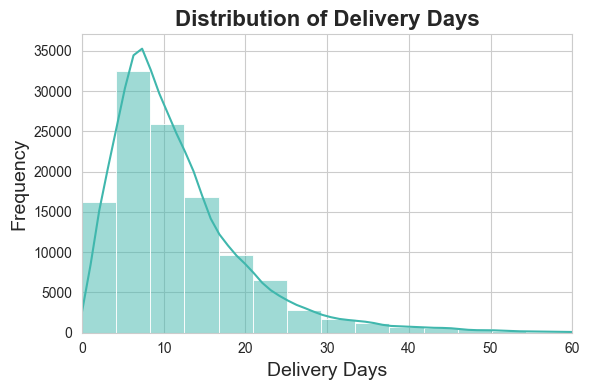

In [42]:
plt.figure(figsize=(6, 4))
sns.histplot(master['delivery_days'].dropna(), bins=50, kde=True, color=sns.color_palette("mako")[4])
plt.title('Distribution of Delivery Days', fontsize=16, fontweight="bold")
plt.xlabel('Delivery Days', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.xlim(0, 60) 
plt.tight_layout()
plt.show()


Total Order Value

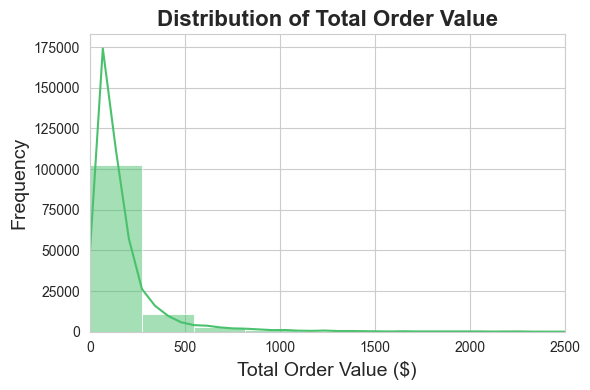

In [43]:
sns.set_style("whitegrid")
plt.figure(figsize=(6,4))
sns.histplot(master['payment_value'], bins=50, kde=True, color=sns.color_palette("viridis")[4])
plt.title('Distribution of Total Order Value', fontsize=16, fontweight="bold")
plt.xlabel('Total Order Value ($)', fontsize=14) 
plt.ylabel('Frequency', fontsize=14)
plt.xlim(0, 2500)
plt.tight_layout()
plt.show()

Order Status Distribution

C:\Users\soumo\AppData\Local\Temp\ipykernel_20996\3179374439.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=order_counts.index, y=order_counts.values, palette="Set1")


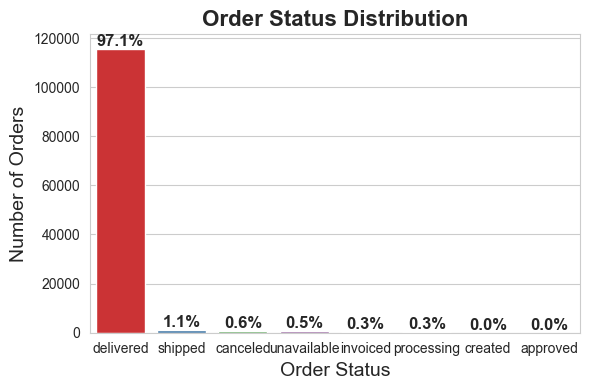

In [44]:
plt.figure(figsize=(6,4))
order_counts = master['order_status'].value_counts()
total_orders = order_counts.sum()
ax = sns.barplot(x=order_counts.index, y=order_counts.values, palette="Set1")
plt.title('Order Status Distribution', fontsize=16, fontweight="bold")  
plt.xlabel('Order Status', fontsize=14)
plt.ylabel('Number of Orders', fontsize=14)

for i, value in enumerate(order_counts.values):
    percentage = (value / total_orders) * 100
    ax.text(i,value,f"{percentage:.1f}%",ha='center',va='bottom',fontsize=12,fontweight='bold')
plt.tight_layout()
plt.show()

Payment Type Distribution

C:\Users\soumo\AppData\Local\Temp\ipykernel_20996\3794765935.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=payment_counts.index, y=payment_counts.values, palette="Set1", legend=False)


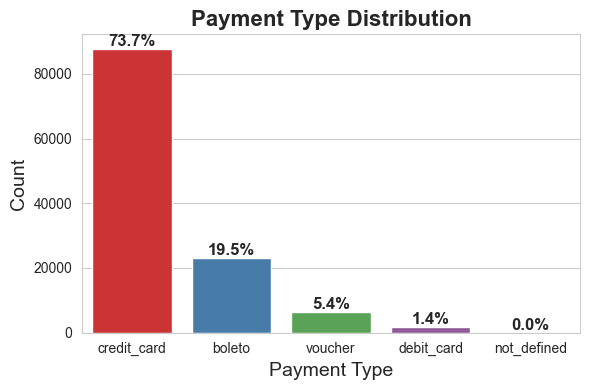

In [45]:
plt.figure(figsize=(6,4))
payment_counts = master['payment_type'].value_counts()
total_payments = payment_counts.sum()
ax = sns.barplot(x=payment_counts.index, y=payment_counts.values, palette="Set1", legend=False)
plt.title('Payment Type Distribution', fontsize=16, fontweight="bold")
plt.xlabel('Payment Type', fontsize=14)
plt.ylabel('Count', fontsize=14)
for i, value in enumerate(payment_counts.values):
    percentage = (value / total_payments) * 100
    ax.text(i,value,f"{percentage:.1f}%",ha='center',va='bottom',fontsize=12,fontweight='bold')

plt.tight_layout()
plt.show()

Top 10 Product Categories

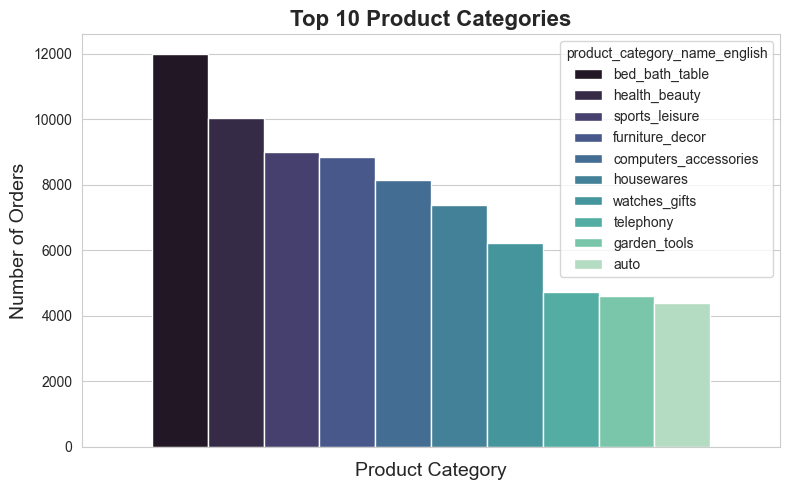

In [48]:
top_categories = master['product_category_name_english'].value_counts().head(10)
plt.figure(figsize=(8,5)) 
sns.barplot(hue=top_categories.index, y=top_categories.values, palette="mako")
plt.title('Top 10 Product Categories', fontsize=16, fontweight="bold")
plt.xlabel('Product Category', fontsize=14)
plt.ylabel('Number of Orders', fontsize=14)
plt.tight_layout()
plt.show()

## Connecting to a Database (MYSQL)

In [53]:
from sqlalchemy import create_engine
from urllib.parse import quote_plus

table_name = 'master_table'
master.to_sql(table_name, engine, if_exists='replace', index=False)

print("Master table successfully loaded!")

username = 'root'
password = quote_plus('@Soumojit2005')
host = 'localhost'
port = '3306'
database = 'Ecommerce'

engine = create_engine(f'mysql+pymysql://{username}:{password}@{host}:{port}/{database}')

table_name = 'master_table'
master.to_sql(table_name, engine, if_exists='replace', index=False)

print(f"Data successfully loaded into table '{table_name}' in database '{database}'.")

Master table successfully loaded!
Data successfully loaded into table 'master_table' in database 'Ecommerce'.


In [54]:
master.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'customer_unique_id', 'customer_zip_code_prefix', 'customer_city',
       'customer_state', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value',
       'product_category_name', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm',
       'seller_zip_code_prefix', 'seller_city', 'seller_state',
       'payment_sequential', 'payment_type', 'payment_installments',
       'payment_value', 'review_id', 'review_score', 'review_comment_title',
       'review_comment_message', 'review_creation_date',
       'review_answer_timestamp', 'product_category_name_english',
       'delivery_days'],
      dtype='object')